In [ ]:
import gymnasium as gym
from morl_baselines.multi_policy.multi_policy_moqlearning.mp_mo_q_learning import (
    MPMOQLearning,
)
import mo_gymnasium as mo_gym
from mo_gymnasium.wrappers.vector.wrappers import MOSyncVectorEnv, MORecordEpisodeStatistics
from morl_baselines.multi_policy.pareto_q_learning.pql import PQL
import numpy as np


: 

In [ ]:
GAMMA = 0.9

ref_point = np.array([-1, -1, -2])

# env = mo_gym.make_vec("resource-gathering-v0", num_envs=1, vectorization_mode="sync", wrappers=(MORecordEpisodeStatistics,))
# env = MOSyncVectorEnv([lambda: mo_gym.make("resource-gathering-v0")])
# env = MORecordEpisodeStatistics(env, gamma=GAMMA)
env = mo_gym.make("resource-gathering-v0")

eval_env = mo_gym.make("resource-gathering-v0")

obs, info = env.reset()


# Your code here:
agent = MPMOQLearning(
    env,
    initial_epsilon=1.0,
    final_epsilon=0.05,
    epsilon_decay_steps=10000,
    gamma=GAMMA,
    dyna=True,
    gpi_pd=True,
    weight_selection_algo="gpi-ls",
    use_gpi_policy=True,
    log=True,
)
agent.train(
    total_timesteps=1000,
    timesteps_per_iteration=100,
    eval_env=eval_env,
    num_eval_episodes_for_front=50,
    ref_point=ref_point,
)


c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\spaces\box.py:236: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
c:\Users\skakr\Documents\Programming\md-morl\.venv\Lib\site-packages\gymnasium\spaces\box.py:306: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


wandb: Currently logged in as: kristofs (kristofs-ai) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


CCS: [] CCS size: 0
Next weight: [1. 0. 0.]
Adding value: [-0.0486  0.      0.    ] to CCS.


In [ ]:
env.pareto_front(0.9)

In [ ]:
agent.linear_support.ccs

In [ ]:
from morl_baselines.common.utils import make_gif

env2 = mo_gym.make("resource-gathering-v0", render_mode='rgb_array')  # you need to set the render_mode to render the gifs

# Your code here:
make_gif(env2, agent, weight=np.array([0.9, 0.1, 0.0]), fps=10, fullpath="./myagent1")
make_gif(env2, agent, weight=np.array([0.3, 0.7, 0.0]), fps=10, fullpath="./myagent2")
make_gif(env2, agent, weight=np.array([0.0, 1.0, 0.0]), fps=10, fullpath="./myagent3")

In [3]:
from matplotlib import pyplot as plt

def viz_front(pareto_front, columns):
    pf_arr = np.array((list(pareto_front)))

    # 2) Log 2D Pareto front projections as scatter plots
    # go through all combinations of columns
    n_pairs = len(columns) * (len(columns) - 1) // 2
    fig, axs = plt.subplots(1, n_pairs, figsize=(5 * n_pairs, 4))
    if n_pairs == 1: # subscriptable even if there's only 1 element
        axs = [axs]

    pair_count = 0
    for i in range(len(columns)):
        for j in range(i + 1, len(columns)):
            ax = axs[pair_count]
            ax.scatter(pf_arr[:, i], pf_arr[:, j], color="black")
            ax.set_xlabel(columns[i])
            ax.set_ylabel(columns[j])
            ax.set_title(f"Pareto front: {columns[i]} vs {columns[j]}")
                        
            pair_count += 1

    plt.show()
    plt.close(fig)
    return fig

In [4]:
import numpy as np

# from morl_baselines.common.weights import equally_spaced_weights, random_weights
# equally_spaced_weights(4, n=25)

foo = np.array([
 np.array([0.82218973, 0.70593715, 0.78828361, 0.15663676]),
 np.array([0.51167258, 0.58654309, 0.90295907, 0.39326163]),
 np.array([0.86395602, 0.62948852, 0.59048645, 0.1954546 ]),
 np.array([0.70455903, 0.90157696, 0.70711434, 0.11663975]),
 np.array([0.86533221, 0.15703177, 0.86118489, 0.54851627]),
 np.array([0.86374229, 0.59185476, 0.39148745, 0.66791329]),
 np.array([0.39326654, 0.35287647, 0.9000166 , 0.9413888 ]),
 np.array([0.705551  , 0.78710052, 0.51225378, 0.3128755 ]),
 np.array([0.94255805, 0.39267252, 0.98059084, 0.23445962]),
 np.array([0.55127947, 0.54949844, 0.94157692, 0.74555297]),
 np.array([0.70692723, 0.47226758, 0.47108845, 0.90275613]),
 np.array([0.31386257, 0.90276598, 0.58910732, 0.51107065]),
 np.array([0.4724666 , 0.23544867, 0.74653217, 0.90433724]),
 np.array([1.09683846, 0.43305768, 0.62909151, 0.51344773]),
 np.array([0.58970132, 1.4102913 , 0.51304286, 0.51148835]),
 np.array([0.8213987 , 0.5504796 , 0.70710747, 0.70595195]),
 np.array([0.47402992, 0.47226367, 0.46990534, 1.02293534]),
 np.array([1.17899975, 0.58635494, 0.66712033, 0.23662488]),
 np.array([0.66536386, 0.19407645, 0.74908946, 0.74611542]),
 np.array([0.74907959, 0.47167753, 0.97940966, 0.5489113 ]),
 np.array([0.62693218, 0.31307255, 1.18116404, 0.39229327]),
 np.array([0.51088348, 0.74788666, 0.86552131, 0.78672223]),
 np.array([0.82946569, 0.07821593, 0.66654403, 1.29445341]),
 np.array([0.94099181, 0.78613017, 0.5883084 , 0.19643477]),
 np.array([1.0995751 , 0.59127255, 0.51049537, 0.39010735]),
 np.array([0.7480886 , 0.51030425, 0.94571733, 0.23504574]),
 np.array([0.5904835 , 0.58850641, 0.82238973, 0.55147256]),
 np.array([1.36913476, 0.62713215, 0.51069633, 0.27622782]),
 np.array([0.15721795, 0.47088257, 0.43483678, 1.45186346]),
 np.array([0.66928654, 0.15604667, 1.06194824, 0.47462394]),
 np.array([0.55146172, 0.23486058, 0.86709454, 0.90551738]),
 np.array([0.78672224, 0.5502993 , 0.47009642, 0.70712225]),
 np.array([0.70711831, 0.50872025, 0.4722686 , 0.78297786]),
 np.array([0.51166865, 0.35326067, 0.67066865, 0.98020173]),
 np.array([0.15526057, 0.47245771, 0.1968298 , 2.00138159]),
 np.array([0.58870244, 1.17919184, 0.3150457 , 0.62772518]),
 np.array([0.82592821, 0.62594711, 0.43286168, 0.39364874]),
 np.array([0.23524276, 0.19466455, 1.06097788, 0.90570552]),
 np.array([0.86453232, 0.5465569 , 0.58831824, 0.67026572]),
 np.array([0.74711433, 0.98117202, 0.35523678, 0.43245676]),
 np.array([0.62593529, 0.82907363, 0.58949937, 0.6271243 ]),
 np.array([0.86454018, 0.54830943, 0.27465662, 0.78612818]),
 np.array([0.4324735 , 0.66574313, 0.47107268, 1.10372039]),
 np.array([0.39482793, 0.90198384, 0.58930136, 0.70712324]),
 np.array([0.43208735, 0.27543779, 0.90473815, 0.78338274]),
 np.array([0.70496192, 0.78652717, 0.58693024, 0.74770344]),
 np.array([0.66614604, 0.98393819, 0.3932636 , 0.39286463]),
 np.array([0.039601  , 0.23504575, 0.67263291, 1.60832875]),
 np.array([0.86160064, 0.43127859, 0.43522392, 0.82317291]),
 np.array([0.31287553, 0.78809739, 0.47146868, 1.14037201]),
 np.array([0.3920805 , 0.43443286, 0.59165279, 0.93764347]),
 np.array([0.70711728, 0.39267054, 0.90297283, 0.67027162]),
 np.array([0.70710746, 0.39208442, 0.78672123, 0.74534411]),
 np.array([0.86474902, 0.59106766, 0.70613322, 0.39582388]),
 np.array([0.15644171, 0.2746527 , 0.119003  , 1.88589538]),
 np.array([0.43226956, 0.27582987, 0.70633415, 1.09918796]),
 np.array([0.74947266, 0.19564867, 0.93782867, 0.70868657]),
 np.array([0.74258288, 0.70829553, 0.62988452, 0.31484375]),
 np.array([0.58831033, 0.58634906, 0.59087359, 0.94492827]),
 np.array([0.23622787, 0.19820698, 0.74889144, 1.33798495]),
 np.array([0.42991523, 0.46950242, 0.94097996, 0.74810435]),
 np.array([0.98038786, 0.55225866, 0.27544075, 0.66851127]),
 np.array([1.0938842 , 0.71066465, 0.58556293, 0.35503384]),
 np.array([0.90433423, 0.31347348, 0.50636879, 0.59028746]),
 np.array([0.03900995, 0.39364779, 0.94472139, 1.3354296 ]),
 np.array([0.59086671, 0.27543778, 0.63027953, 0.9841175 ]),
 np.array([0.62929345, 0.86139179, 0.55009639, 0.39483778]),
 np.array([0.7861105 , 0.66515207, 0.90140064, 0.50970041]),
 np.array([0.5124626 , 0.70593518, 0.62792518, 0.78770239]),
 np.array([0.        , 0.079401  , 0.        , 2.52187666]),
 np.array([0.2360358 , 0.0796    , 0.43286064, 1.57716319]),
 np.array([0.        , 0.31740599, 0.39404773, 1.92530724]),
 np.array([0.0398    , 0.31386457, 0.67223591, 1.64554389]),
 np.array([0.58851525, 0.35464867, 0.82610749, 0.86395306]),
 np.array([0.47147655, 0.43424471, 0.46775287, 1.05959973]),
 np.array([0.90532526, 0.78671635, 0.35425663, 0.35562885]),
 np.array([1.25681962, 0.4324617 , 0.54754004, 0.1172298 ]),
 np.array([0.62634899, 0.54871628, 0.78455008, 0.63205868]),
 np.array([0.2764288 , 0.98019088, 0.47030036, 0.86690636]),
 np.array([0.07822182, 0.198602  , 0.3554328 , 1.60948626]),
 np.array([0.3550378 , 0.43305372, 0.586946  , 0.97863639]),
 np.array([0.51206958, 0.11781594, 0.90591336, 1.02137197]),
 np.array([1.01743455, 0.9449322 , 0.2752457 , 0.35327249]),
 np.array([0.74555295, 0.90670049, 0.50656483, 0.59067559]),
 np.array([0.        , 0.079401  , 0.079401  , 2.24329735]),
 np.array([0.        , 0.278003  , 0.15840499, 2.00431129]),
 np.array([0.079401  , 0.19742282, 0.67007657, 1.68791299]),
 np.array([0.19761097, 0.54870836, 0.3538586 , 1.73320195]),
 np.array([0.70751136, 0.51009739, 0.86415305, 0.6312686 ]),
 np.array([0.70319464, 0.74751033, 0.74613026, 0.51147259]),
 np.array([0.51047764, 0.78534112, 0.66791136, 0.50990136]),
 np.array([0.03862082, 0.19701993, 0.        , 2.19504624]),
 np.array([0.51086873, 0.50872514, 0.31366457, 1.05822554]),
 np.array([0.9843283 , 0.78180859, 0.23485465, 0.67125082]),
 np.array([0.59008253, 0.62929541, 0.62910824, 0.5128478 ]),
 np.array([0.        , 0.039601  , 0.11802182, 2.20487656]),
 np.array([0.27564072, 0.079401  , 0.19721694, 1.92530922]),
 np.array([0.27602984, 0.59303885, 0.86591931, 1.01980369]),
 np.array([0.23761195, 1.17939674, 0.15605062, 0.54635891]),
 np.array([0.23662092, 1.01823642, 0.43286757, 1.3003443 ]),
 np.array([0.        , 0.23800499, 0.11860698, 2.08448359]),
 np.array([0.15800997, 0.27406457, 0.19761395, 1.96295281]),
 np.array([0.0398    , 0.11781889, 0.66928949, 1.72965662]),
 np.array([0.27564072, 0.82533222, 0.39325078, 1.25426035]),
 np.array([0.31524271, 0.39188444, 0.51107265, 1.49422569]),
 np.array([0.        , 0.0796    , 0.        , 2.36483703]),
 np.array([0.11761893, 0.3542517 , 0.2764239 , 1.80943883]),
 np.array([0.19761395, 0.19761296, 0.43109142, 1.96196282]),
 np.array([0.        , 0.11841095, 0.27740898, 2.16271132]),
 np.array([0.        , 0.58890338, 0.31720799, 1.37069914]),
 np.array([0.119201  , 0.39385366, 0.079401  , 2.16371902]),
 np.array([0.23701989, 0.19663672, 0.079202  , 2.0856785 ]),
 np.array([0.       , 0.0398   , 0.079401 , 2.3246459]),
 np.array([0.        , 0.        , 0.        , 2.84814359]),
 np.array([0.        , 0.        , 0.0398    , 2.60010832]),
 np.array([0.        , 0.0398    , 0.        , 2.64383491]),
 np.array([0.1572229 , 0.079401  , 1.25779095, 0.0780199 ]),
 np.array([0.1178199 , 1.02039673, 0.15644464, 0.97941166]),
 np.array([0.27721593, 1.89299397, 0.0398    , 0.19663672]),
 np.array([0.35523777, 0.31503387, 1.38054323, 0.0398    ]),
 np.array([0.79123593, 1.91959966, 0.23741296, 0.        ]),
 np.array([2.12863082, 0.03900995, 1.24798721, 0.07900399]),
 np.array([2.20387272, 0.0398    , 0.079203  , 0.        ]),
 np.array([2.28525867, 0.        , 0.15683083, 0.        ]),
 np.array([0.19782083, 1.22744788, 0.55106275, 0.        ]),
 np.array([0.75223784, 1.25424946, 0.38971627, 0.        ]),
 np.array([2.59262263, 0.31464869, 0.039403  , 0.        ]),
 np.array([0.59362694, 0.43286064, 1.5757821 , 0.        ]),
 np.array([1.30469154, 0.27445268, 1.05329023, 0.        ]),
 np.array([1.6128258 , 1.09310791, 0.0388149 , 0.        ]),
 np.array([0.        , 0.        , 2.09591458, 0.        ]),
 np.array([1.68986752, 0.66752813, 0.079401  , 0.        ]),
 np.array([1.84452613, 0.15604274, 0.62163038, 0.        ]),
 np.array([2.43855599, 0.74339557, 0.        , 0.        ]),
 np.array([1.18253325, 1.0519278 , 0.27209733, 0.        ]),
 np.array([0.039403  , 0.039403  , 1.37955815, 0.0786149 ]),
 np.array([0.238601  , 0.98471148, 0.70712322, 0.        ]),
 np.array([0.47384177, 0.039403  , 1.92373699, 0.        ]),
 np.array([0.9474767 , 1.60613996, 0.34992414, 0.        ]),
 np.array([0.51423777, 0.        , 1.84312929, 0.        ]),
 np.array([1.73320888, 0.66573919, 0.73965615, 0.        ]),
 np.array([1.45875224, 0.03920598, 1.09056141, 0.        ]),
 np.array([0.63126858, 0.        , 1.36753996, 0.        ]),
 np.array([0.63245468, 1.693399  , 0.        , 0.0398    ]),
 np.array([0.87024883, 2.19916688, 0.        , 0.        ]),
 np.array([1.38033139, 1.28757344, 0.        , 0.        ]),
 np.array([2.12941894, 0.89765429, 0.        , 0.        ]),
 np.array([0.39660899, 0.        , 2.01197628, 0.        ]),
 np.array([1.14470844, 1.5675004 , 0.        , 0.        ]),
 np.array([0.238601  , 0.        , 2.08760725, 0.        ])])
foo

array([[0.82218973, 0.70593715, 0.78828361, 0.15663676],
       [0.51167258, 0.58654309, 0.90295907, 0.39326163],
       [0.86395602, 0.62948852, 0.59048645, 0.1954546 ],
       [0.70455903, 0.90157696, 0.70711434, 0.11663975],
       [0.86533221, 0.15703177, 0.86118489, 0.54851627],
       [0.86374229, 0.59185476, 0.39148745, 0.66791329],
       [0.39326654, 0.35287647, 0.9000166 , 0.9413888 ],
       [0.705551  , 0.78710052, 0.51225378, 0.3128755 ],
       [0.94255805, 0.39267252, 0.98059084, 0.23445962],
       [0.55127947, 0.54949844, 0.94157692, 0.74555297],
       [0.70692723, 0.47226758, 0.47108845, 0.90275613],
       [0.31386257, 0.90276598, 0.58910732, 0.51107065],
       [0.4724666 , 0.23544867, 0.74653217, 0.90433724],
       [1.09683846, 0.43305768, 0.62909151, 0.51344773],
       [0.58970132, 1.4102913 , 0.51304286, 0.51148835],
       [0.8213987 , 0.5504796 , 0.70710747, 0.70595195],
       [0.47402992, 0.47226367, 0.46990534, 1.02293534],
       [1.17899975, 0.58635494,

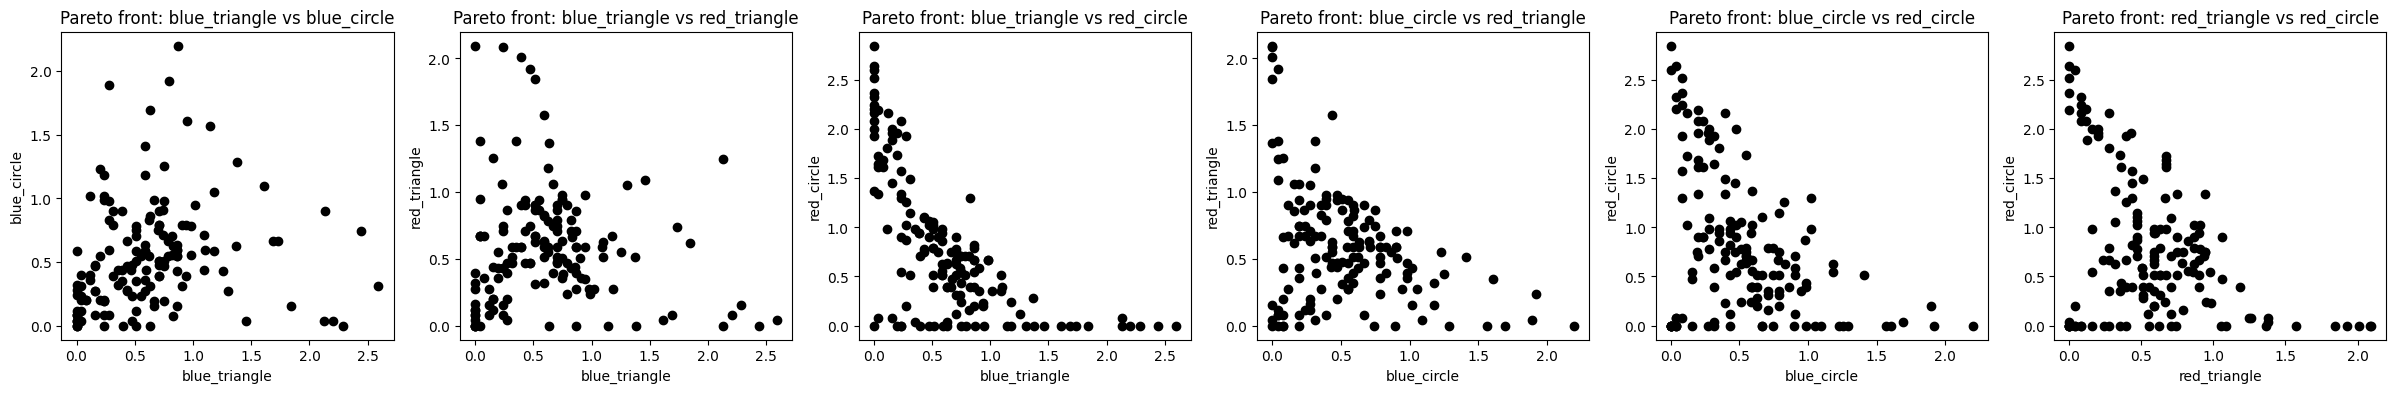

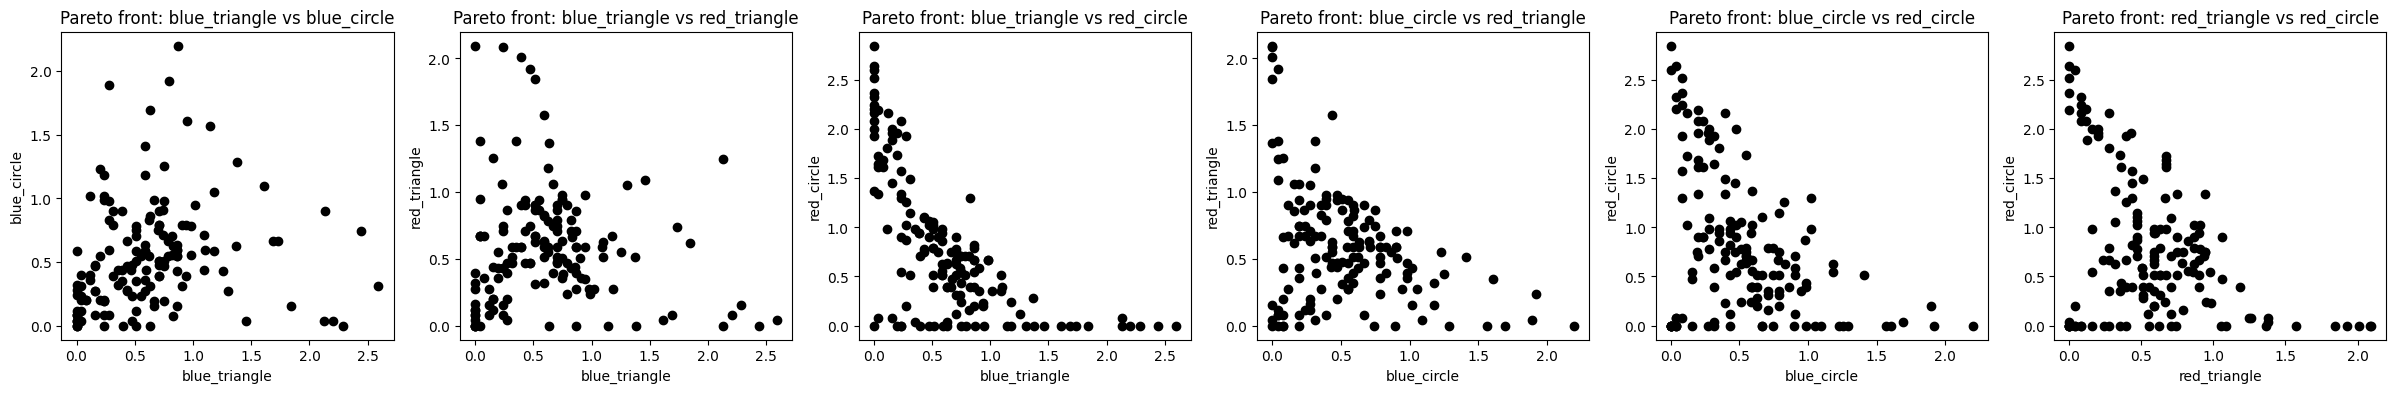

In [ ]:
remove_dominated
viz_front(foo, columns=["blue_triangle", "blue_circle", "red_triangle", "red_circle"])